In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, RFE


In [2]:
df=pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv')

In [3]:
df.columns

Index(['Unnamed: 0', 'composition', 'A', 'B', 'B_prime', 'X', 'cif_file',
       'formula', 'n_inequivalent', 'reduction_ratio',
       ...
       'X_atomic_nfunf', 'X_atomic_nfval', 'X_atomic_npunf', 'X_atomic_npval',
       'X_atomic_nsunf', 'X_atomic_nsval', 'X_atomic_nunf', 'X_atomic_nval',
       'X_atomic_pol', 'formation_energy_per_atom'],
      dtype='object', length=357)

In [4]:
def extract_ce_features_from_df(df):

    ce_prefixes = ['C_', 'E_', 'D_', 'R_']

    ce_cols = [col for col in df.columns if col[:2] in ce_prefixes]

    X_CE = df[ce_cols]

    print(f"--- CE 特征提取报告 ---")
    print(f"总特征数列数: {df.shape[1]}")
    print(f"提取出 CE 特征数: {X_CE.shape[1]}")

    if X_CE.shape[1] > 0:
        print(f"示例特征: {list(X_CE.columns[:5])}")
    else:
        print("警告: 未提取到任何 CE 特征，请检查列名是否包含 C_, E_, D_, R_ 前缀")
        
    return X_CE, ce_cols

X_CE, ce_feature_names = extract_ce_features_from_df(df)

--- CE 特征提取报告 ---
总特征数列数: 357
提取出 CE 特征数: 148
示例特征: ['C_Atomic number start counting left top, left-right sequence', 'C_Atomic weight', 'C_Boiling temperature', 'C_Compression modulus', 'C_Density']


In [5]:
X_CE['formation_energy_per_atom']=df['formation_energy_per_atom']

/tmp/ipykernel_29862/4098935075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_CE['formation_energy_per_atom']=df['formation_energy_per_atom']


In [6]:
X_CE

,"C_Atomic number start counting left top, left-right sequence",C_Atomic weight,C_Boiling temperature,C_Compression modulus,C_Density,C_Distance from core electron (Schubert),C_Distance from valence electron (Schubert),C_Electrochemical weight equivalent,C_Electron affinity,C_Electronegativity (Pauling),...,R_Oxidation state first,"R_Periodic number start counting bottom right, right-left sequence","R_Periodic number start counting left bottom, left-right sequence","R_Periodic number start counting top right, right-left sequence",R_Radii covalent,R_Radii metal (Waber),R_Radii pseudo-potential (Zunger),R_Valence electron number,"R_Volume of atom (Villars, Daams)",formation_energy_per_atom
0,20.865987,45.079198,1675.216617,0.294317,3208.113908,1.001348,1.848293,0.478144,72.296803,2.172610,...,-1.172788,0.978936,1.024456,5.047276,1.566377,1.365147,3.686823,1.185978,1.349123,-3.478282
1,26.854346,62.005572,2122.354202,0.366397,4562.451982,0.980487,1.728129,0.531031,76.899063,2.213472,...,-1.053807,1.047957,1.268353,6.832446,1.486522,1.265564,4.485948,1.079362,1.147138,-3.497675
2,40.782153,99.050518,2246.117409,0.615377,6718.114623,1.049925,1.967927,0.663133,68.324765,2.166047,...,-1.073187,1.222814,1.757543,8.900868,1.620213,1.403182,3.923727,1.115574,1.516566,-3.269091
3,27.118823,62.155009,2147.362015,0.386984,4120.207524,0.971223,1.724514,0.531638,76.882457,2.214194,...,-1.053323,1.051789,1.258140,6.763001,1.485825,1.293826,4.468701,1.079685,1.143649,-3.481524
4,29.019449,66.972134,1367.643215,0.577725,4406.777457,0.922530,1.564523,0.531821,92.250273,2.218344,...,-1.000000,1.066897,1.199977,6.460086,1.518277,1.265467,4.071110,1.023584,1.247637,-2.718079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,27.159195,62.551138,1580.372314,0.267979,3518.847586,1.040032,1.914742,0.570999,68.832343,2.133564,...,-1.040921,1.005143,1.104266,6.308877,1.636223,1.416012,4.107707,1.219076,1.488026,-3.298078
828,37.637602,90.391488,1653.737381,0.133410,4372.324354,1.101867,2.117826,0.700889,74.893571,2.046582,...,-1.083946,1.152698,2.083587,9.531218,1.720837,1.473012,4.815595,1.288701,1.716508,-3.333380
829,30.617966,72.093971,1650.142337,0.358566,3791.900318,1.059062,2.015488,0.623176,74.710646,2.127517,...,-1.033553,1.074961,1.510492,7.999588,1.635863,1.417553,4.278069,1.174698,1.549139,-3.058659
830,31.224599,72.838545,1249.380979,0.370682,4413.153674,1.128258,2.110569,0.580948,90.244083,2.298144,...,-1.040387,1.013489,1.065020,5.675573,1.609712,1.390513,3.409876,1.047525,1.499527,-1.953905


In [7]:
X_CE.to_csv('/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ce_ef.csv')

In [8]:
CSV_PATH = '/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ce_ef.csv'  # 替换为你的文件路径
TARGET_COL = 'formation_energy_per_atom'  # 目标变量名
DROP_COLS = ['Unnamed: 0', 'composition', 'A', 'B', 'B_prime', 'X', 'cif_file','formula', 'n_inequivalent'] 

In [9]:
def load_data(path):
    print(f"Loading data from {path}...")
    df = pd.read_csv(path)
    
    # 1. 移除无关列 (只保留数值特征和目标)
    # 使用 errors='ignore' 防止列不存在报错
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    # 2. 清洗数据 (移除 NaN 和 Inf)
    initial_len = len(df)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"Data cleaned: {initial_len} -> {len(df)} samples")
    
    # 3. 分离 X 和 y
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]
    
    print(f"Initial Feature Count: {X.shape[1]}")
    return X, y

In [10]:
def feature_reduction(X_train, X_test, y_train, n_features_to_select=30):
    print("\n--- Starting Feature Reduction ---")
    
    # Step 1: 移除方差为 0 的列 (常量特征)
    selector_var = VarianceThreshold(threshold=0)
    X_train_var = selector_var.fit_transform(X_train)
    X_test_var = selector_var.transform(X_test)
    
    # 获取保留的列名
    valid_cols = X_train.columns[selector_var.get_support()]
    # 修复版
    X_train = pd.DataFrame(X_train_var, columns=valid_cols, index=X_train.index)
    X_test = pd.DataFrame(X_test_var, columns=valid_cols, index=X_test.index)
    print(f"[Step 1] Constant features removed. Remaining: {X_train.shape[1]}")
    
    # Step 2: 移除高相关特征 (Pearson > 0.95)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    
    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)
    print(f"[Step 2] Collinear features removed (>0.95). Remaining: {X_train.shape[1]}")
    
    # Step 3: RFE (递归特征消除)
    print(f"[Step 3] Running RFE to select top {n_features_to_select} features...")
    
    estimator = RandomForestRegressor(n_estimators=50, n_jobs=1, random_state=42) 
    
    selector = RFE(estimator, n_features_to_select=n_features_to_select, step=0.1)
    selector = selector.fit(X_train, y_train)
    
    valid_cols = X_train.columns[selector.support_]
    X_train_final = pd.DataFrame(selector.transform(X_train), columns=valid_cols)
    X_test_final = pd.DataFrame(selector.transform(X_test), columns=valid_cols)
    
    print(f"Final Feature Set: {list(valid_cols[:5])} ...")
    return X_train_final, X_test_final

In [11]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- Test Set Performance ---")
    print(f"MAE : {mae:.4f} eV/atom")
    print(f"RMSE: {rmse:.4f} eV/atom")
    print(f"R2  : {r2:.4f}")
    
    # --- Plot A: Parity Plot ---
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, c='blue', edgecolor='k')
    
    # 画对角线
    min_val = min(y_test.min(), y_pred.min()) - 0.1
    max_val = max(y_test.max(), y_pred.max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.xlabel('DFT Formation Energy (eV/atom)')
    plt.ylabel('ML Predicted Energy (eV/atom)')
    plt.title(f'Parity Plot (R2={r2:.3f})')
    plt.grid(True, alpha=0.3)
    
    # --- Plot B: Feature Importance ---
    plt.subplot(1, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_n = 20 # 只画前 15 个
    
    plt.barh(range(top_n), importances[indices[:top_n]], align='center', color='teal')
    plt.yticks(range(top_n), [X_test.columns[i] for i in indices[:top_n]])
    plt.xlabel('Relative Importance')
    plt.title('Top 15 Important Features')
    plt.gca().invert_yaxis() # 让最重要的在上面
    
    plt.tight_layout()
    plt.show()


In [13]:
import numpy as np
X, y = load_data(CSV_PATH)

Loading data from /home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ce_ef.csv...
Data cleaned: 832 -> 832 samples
Initial Feature Count: 148


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

def feature_reduction_auto(X_train, X_test, y_train):
    print("\n--- Starting Automatic Feature Reduction (RFECV) ---")
    
    # Step 1: 移除方差为 0 的列 (保留，这步很快且必须)
    selector_var = VarianceThreshold(threshold=0)
    X_train_var = selector_var.fit_transform(X_train)
    X_test_var = selector_var.transform(X_test)
    
    valid_cols = X_train.columns[selector_var.get_support()]
    X_train = pd.DataFrame(X_train_var, columns=valid_cols, index=X_train.index)
    X_test = pd.DataFrame(X_test_var, columns=valid_cols, index=X_test.index)
    
    estimator = XGBRegressor(n_estimators=100, max_depth=3, n_jobs=-1, random_state=42)

    selector = RFECV(
        estimator=estimator, 
        step=1, 
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='neg_mean_absolute_error',
        min_features_to_select=5,
        n_jobs=-1 # 并行加速
    )
    
    print("Running RFECV... (This might take a while)")
    selector.fit(X_train, y_train)

    optimal_n = selector.n_features_
    print(f"✅ Optimal number of features found: {optimal_n}")
    
    valid_cols = X_train.columns[selector.support_]
    X_train_final = pd.DataFrame(selector.transform(X_train), columns=valid_cols, index=X_train.index)
    X_test_final = pd.DataFrame(selector.transform(X_test), columns=valid_cols, index=X_test.index)
    
    print(f"Final Feature Set: {list(valid_cols[:5])} ...")
    try:
        plt.figure(figsize=(8, 4))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross validation score (Neg MAE)")
        # cv_results_['mean_test_score'] 是最新版 sklearn 的用法
        scores = selector.cv_results_['mean_test_score']
        plt.plot(range(5, len(scores) + 5), scores) # 假设 step=1
        plt.title(f"Optimal features: {optimal_n}")
        plt.show()
    except:
        pass

    return X_train_final, X_test_final


--- Starting Automatic Feature Reduction (RFECV) ---
Running RFECV... (This might take a while)


/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the '

✅ Optimal number of features found: 60
Final Feature Set: ['C_Atomic number start counting left top, left-right sequence', 'C_Compression modulus', 'C_Distance from core electron (Schubert)', 'C_Distance from valence electron (Schubert)', 'C_Electrochemical weight equivalent'] ...


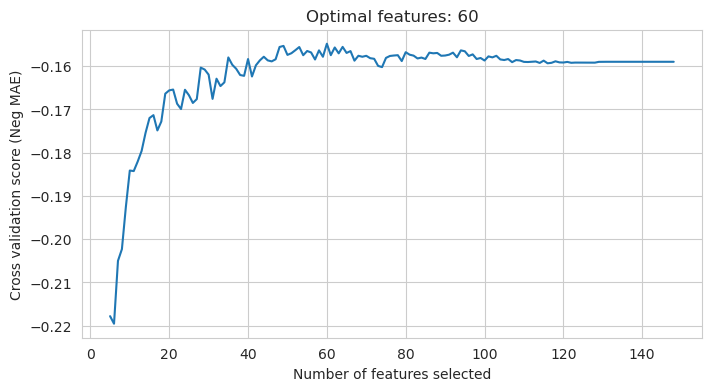

(     C_Atomic number start counting left top, left-right sequence  \
 477                                          41.538659              
 346                                          42.549557              
 462                                          34.945826              
 671                                          37.013571              
 302                                          45.460167              
 ..                                                 ...              
 71                                           35.385544              
 106                                          31.170976              
 270                                          15.044520              
 435                                          27.873252              
 102                                          19.625235              
 
      C_Compression modulus  C_Distance from core electron (Schubert)  \
 477               0.746431                                  1.025683   
 346        

In [16]:
from xgboost import XGBRegressor
feature_reduction_auto(X_train, X_test, y_train)

In [17]:
def tune_and_train_xgboost(X_train, y_train):
    print("\n--- Starting Hyperparameter Tuning (XGBoost) ---")

    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)

    param_dist = {

        'n_estimators': randint(500, 1500),
        
        'learning_rate': uniform(0.01, 0.1),

        'max_depth': randint(3, 8),

        'subsample': uniform(0.6, 0.4),       # 0.6 ~ 1.0
        'colsample_bytree': uniform(0.6, 0.4), # 0.6 ~ 1.0
        
        'reg_alpha': uniform(0, 0.5),
        'reg_lambda': uniform(0.5, 1.0)
    }
    
    # 3. 随机搜索
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=500,     
        cv=5,       
        scoring='neg_mean_absolute_error',
        n_jobs=4,       
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_


# 增强版

In [28]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform 

def tune_and_train_xgboost_enhanced(X_train, y_train):
    print("\n--- Starting Enhanced Hyperparameter Tuning (XGBoost) ---")

    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)

    param_dist = {
        'n_estimators': randint(500, 3000),
        'learning_rate': loguniform(0.005, 0.2),

        'max_depth': randint(3, 12),

        'min_child_weight': randint(1, 10), 

        'subsample': uniform(0.5, 0.5),    
        'colsample_bytree': uniform(0.5, 0.5), 

        'gamma': uniform(0, 0.5),
        'reg_alpha': loguniform(1e-3, 10.0),  
        'reg_lambda': loguniform(1e-3, 10.0)
    }

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=1000,    
        cv=10,       
        scoring='neg_mean_absolute_error',
        n_jobs=-1,  
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_

In [29]:
X_train_red, X_test_red = feature_reduction(X_train, X_test, y_train, n_features_to_select=58)
best_model = tune_and_train_xgboost_enhanced(X_train_red, y_train)
evaluate_model(best_model, X_test_red, y_test)


--- Starting Feature Reduction ---
[Step 1] Constant features removed. Remaining: 148
[Step 2] Collinear features removed (>0.95). Remaining: 86
[Step 3] Running RFE to select top 58 features...
Final Feature Set: ['C_Atomic number start counting left top, left-right sequence', 'C_Boiling temperature', 'C_Compression modulus', 'C_Density', 'C_Distance from core electron (Schubert)'] ...

--- Starting Enhanced Hyperparameter Tuning (XGBoost) ---
Fitting 10 folds for each of 1000 candidates, totalling 10000 fits


/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the '

Traceback (most recent call last):
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 426, in _process_worker
    call_item = call_queue.get(block=True, timeout=timeout)
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/multiprocessing/queues.py", line 108, in get
    if not self._rlock.acquire(block, timeout):
KeyboardInterrupt

Traceback (most recent call last):
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 426, in _process_worker
    call_item = call_queue.get(block=True, timeout=timeout)
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/multiprocessing/queues.py", line 108, in get
    if not self._rlock.acquire(block, timeout):
KeyboardInterrupt

Traceback (most recent call last):
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/joblib/externals/loky/proces

n3.10/site-packages/xgboost/training.py", line 181, in train
    bst.update(dtrain, iteration=i, fobj=obj)
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/joblib/parallel.py", line 598, in <listcomp>
    return [func(*args, **kwargs)
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py", line 2113, in update
    _LIB.XGBoosterUpdateOneIter(
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py", line 738, in inner_f
    return func(**kwargs)
KeyboardInterrupt
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/training.py", line 181, in train
    bst.update(dtrain, iteration=i, fobj=obj)
  File "/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y

KeyboardInterrupt: 

# svr

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

def evaluate_model(model, X_test, y_test, save_path=None):

    print("\n--- Model Evaluation ---")

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE:  {mae:.4f} eV/atom")
    print(f"RMSE: {rmse:.4f} eV/atom")
    print(f"R2:   {r2:.4f}")

    if save_path:
        print(f"正在保存预测结果到: {save_path} ...")
        indices = X_test.index if hasattr(X_test, 'index') else range(len(y_test))
        
        result_df = pd.DataFrame({
            'True_Value': y_test.values if hasattr(y_test, 'values') else y_test,
            'Predicted_Value': y_pred
        }, index=indices)
        
        result_df.to_csv(save_path)
        print("保存成功！")
    
    plt.figure(figsize=(14, 6))
    
    # 图 1: 真实值 vs 预测值
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Data')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
    plt.xlabel('DFT Calculated Gap (eV)')
    plt.ylabel('ML Predicted Gap (eV)')
    plt.title(f'Prediction Accuracy (R2={r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 图 2: 特征重要性
    plt.subplot(1, 2, 2)
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps.get('svr'), 'feature_importances_'): # SVR通常没有这个，但这行是安全检查
        importances = model.named_steps['svr'].feature_importances_
    else:
        print("Calculating Permutation Importance (this may take a moment)...")
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
        importances = result.importances_mean
        
    if importances is not None:
        indices = np.argsort(importances)[::-1]
        top_n = min(20, len(X_test.columns))
        plt.title("Feature Importance")
        plt.bar(range(top_n), importances[indices[:top_n]], align="center", color='green', alpha=0.7)
        plt.xticks(range(top_n), X_test.columns[indices[:top_n]], rotation=45, ha='right')
        plt.xlim([-1, top_n])
        plt.tight_layout()
    
    plt.show()

In [31]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

def tune_and_train_svr(X_train, y_train):
    print("\n--- Starting Hyperparameter Tuning (SVR) ---")

    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('svr', SVR())
    ])

    param_dist = {
        'svr__kernel': ['rbf'], 

        'svr__C': loguniform(1e-1, 1e3), 

        'svr__gamma': loguniform(1e-3, 1.0),

        'svr__epsilon': loguniform(1e-3, 1e-1)
    }
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=500,  
        cv=10,       
        scoring='neg_mean_absolute_error',
        n_jobs=-1,       
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_

In [32]:
X_train_red, X_test_red = feature_reduction(X_train, X_test, y_train, n_features_to_select=60)
best_model = tune_and_train_svr(X_train_red, y_train)


--- Starting Feature Reduction ---
[Step 1] Constant features removed. Remaining: 148
[Step 2] Collinear features removed (>0.95). Remaining: 86
[Step 3] Running RFE to select top 60 features...
Final Feature Set: ['C_Atomic number start counting left top, left-right sequence', 'C_Boiling temperature', 'C_Compression modulus', 'C_Density', 'C_Distance from core electron (Schubert)'] ...

--- Starting Hyperparameter Tuning (SVR) ---
Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Best Params: {'svr__C': 33.67819821522131, 'svr__epsilon': 0.007886622327732804, 'svr__gamma': 0.007579356154838334, 'svr__kernel': 'rbf'}
Best CV MAE: 0.1145 eV/atom



--- Model Evaluation ---
MAE:  0.0977 eV/atom
RMSE: 0.1963 eV/atom
R2:   0.9164
正在保存预测结果到: results_ce_structure.csv ...
保存成功！
Calculating Permutation Importance (this may take a moment)...


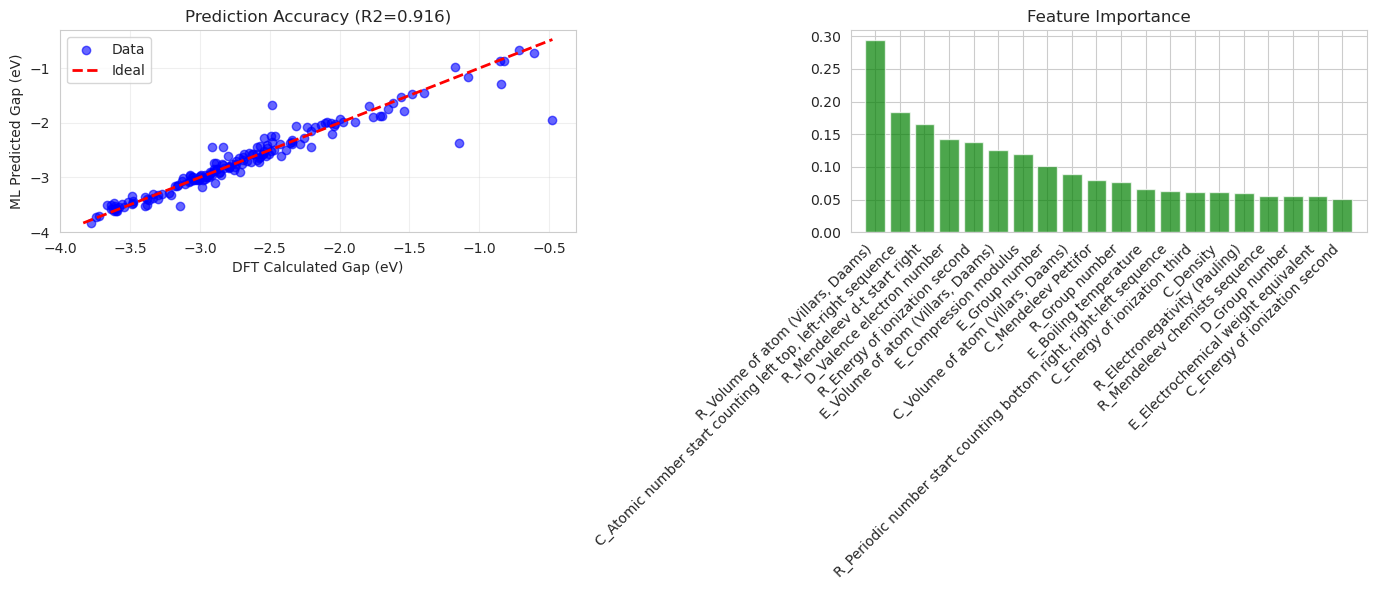

In [33]:
evaluate_model(best_model, X_test_red, y_test,save_path='results_ce_structure.csv')